In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

In [3]:
data = pd.read_csv('C:\myfols\MSC\sem2\TSP\CO2 Concentration.xls')

In [4]:
data

,Year,Month,CO2 Concentration
0,1975,1,330.62
1,1975,2,331.40
2,1975,3,331.87
3,1975,4,333.18
4,1975,5,333.92
...,...,...,...
139,1986,8,345.55
140,1986,9,344.21
141,1986,10,343.67
142,1986,11,345.09


In [5]:
# concate year and month to create a date column
data['Date'] = data['Year'].astype(str) + '-' + data['Month'].astype(str)

In [6]:
data['Date']

0       1975-1
1       1975-2
2       1975-3
3       1975-4
4       1975-5
        ...   
139     1986-8
140     1986-9
141    1986-10
142    1986-11
143    1986-12
Name: Date, Length: 144, dtype: object

In [7]:
data

,Year,Month,CO2 Concentration,Date
0,1975,1,330.62,1975-1
1,1975,2,331.40,1975-2
2,1975,3,331.87,1975-3
3,1975,4,333.18,1975-4
4,1975,5,333.92,1975-5
...,...,...,...,...
139,1986,8,345.55,1986-8
140,1986,9,344.21,1986-9
141,1986,10,343.67,1986-10
142,1986,11,345.09,1986-11


In [8]:
## drop year and month columns
data = data.drop(['Year', 'Month'], axis=1)

In [9]:
data

,CO2 Concentration,Date
0,330.62,1975-1
1,331.40,1975-2
2,331.87,1975-3
3,333.18,1975-4
4,333.92,1975-5
...,...,...
139,345.55,1986-8
140,344.21,1986-9
141,343.67,1986-10
142,345.09,1986-11


In [10]:
#convert 'Month' column to datetime
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')

In [11]:
data

,CO2 Concentration
Date,
1975-01-01,330.62
1975-02-01,331.40
1975-03-01,331.87
1975-04-01,333.18
1975-05-01,333.92
...,...
1986-08-01,345.55
1986-09-01,344.21
1986-10-01,343.67


Text(0.5, 1.0, 'Monthly CO2 Concentration Over Time')

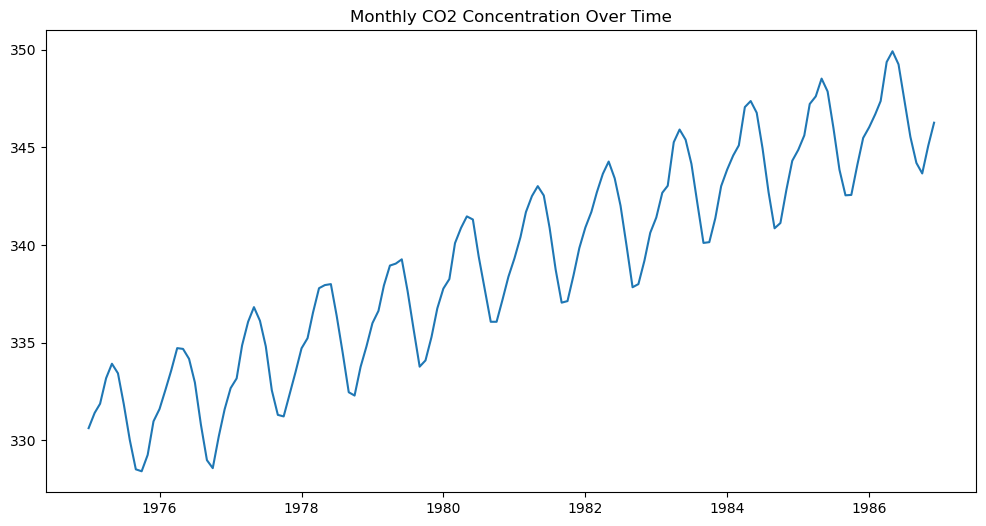

In [12]:
plt.figure(figsize=(12,6))
plt.plot(data['CO2 Concentration'], label='CO2 Concentration')
plt.title('Monthly CO2 Concentration Over Time')

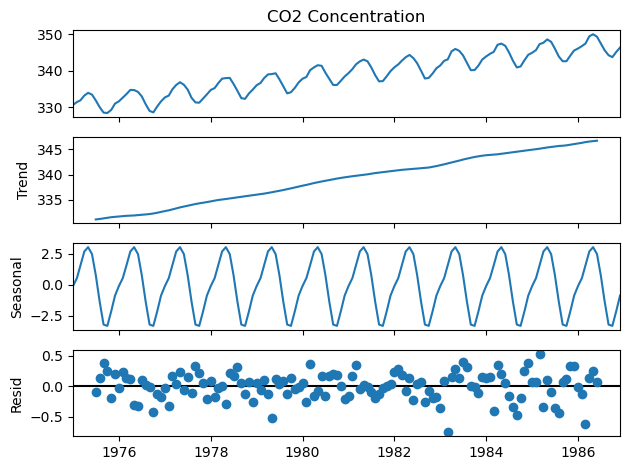

In [14]:
result = seasonal_decompose(data['CO2 Concentration'], model='additive', period=12)
result.plot()
plt.show()

In [15]:
import pymannkendall as mk

## Perform Mann-Kendall Trend Test
## H0: There is no monotonic trend in the series

mk.original_test(data['CO2 Concentration'])


Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(13.22737013469656), Tau=np.float64(0.7438811188811189), s=np.float64(7659.0), var_s=np.float64(335184.3333333333), slope=np.float64(0.11999999999999982), intercept=np.float64(330.545))

In [17]:
## train test split
train_df = data[:int(len(data) * 0.7)]
test_df = data[int(len(data) * 0.7):]

In [18]:
train_df

,CO2 Concentration
Date,
1975-01-01,330.62
1975-02-01,331.40
1975-03-01,331.87
1975-04-01,333.18
1975-05-01,333.92
...,...
1982-12-01,340.63
1983-01-01,341.41
1983-02-01,342.68
